<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/5_Modelos_de_clasificaci%C3%B3n_avanzado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de datos y aprendizaje automático**
---

# **5. Modelos de clasificación**

In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'diabetes.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

diabetes_df = pd.read_csv(ruta_archivo)

In [ ]:
# Características y etiquetas separadas

caracteristica = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
etiqueta = 'Diabetic'

X = diabetes_df[caracteristica].values # Entrada
Y = diabetes_df[etiqueta].values # Salida

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en un 70%-30% en el conjunto de entrenamiento y el conjunto de validación
X_train, X_test, y_train, y_test = train_test_split(diabetes_df[caracteristica], diabetes_df[etiqueta], test_size=0.30, random_state=0)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=0) #Otra forma

print ('Instancias de entrenamiento: %d\nInstancias de validación: %d' % (X_train.shape[0], X_test.shape[0]))

Instancias de entrenamiento: 10500
Instancias de validación: 4500


Veamos como aplicar un preprocesamiento y entrennamiento usando la clase **Pipeline**

In [ ]:
# Train the model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define preprocessing for numeric columns (normalize them so they're on the same scale)
numeric_features = [0,1,2,3,4,5,6]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode the Age column)
categorical_features = [7]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
reg = 0.01
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('logregressor', LogisticRegression(C=1/reg, solver="liblinear"))])


# fit the pipeline to train a logistic regression model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('logregressor',
                 LogisticRegression(C=100.0, solver='liblinear'))])


In [ ]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('logregressor',
                 LogisticRegression(C=100.0, solver='liblinear'))])

El proceso encapsula los pasos de preprocesamiento y entrenamiento del modelo.

Utilicemos el modelo entrenado por este proceso para predecir las etiquetas de nuestro conjunto de pruebas y comparemos las métricas de rendimiento con el modelo básico que creamos anteriormente.

In [ ]:
results_test = pd.DataFrame(columns = ['Modelo',"Accuracy",'Overall_Precision',"Overall_Recall","Overall_F1","AUC"])

Confusion Matrix:
 [[2667  319]
 [ 406 1108]] 

Accuracy: 0.8388888888888889
Overall Precision: 0.7764540995094604
Overall Recall: 0.7318361955085865
Overall F1 score: 0.7534852091125468
AUC: 0.9202442751333613


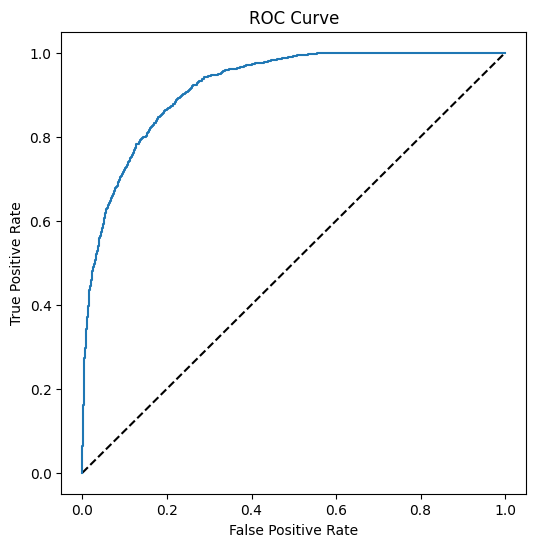

In [ ]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score,roc_auc_score,roc_curve

# Get predictions from test data
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Get evaluation metrics
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n',cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))
print("Overall F1 score:",f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo":"LogisticRegression",
"Accuracy":accuracy_score(y_test, predictions),
"Overall_Precision":precision_score(y_test, predictions),
"Overall_Recall":recall_score(y_test, predictions),
"Overall_F1":f1_score(y_test, predictions),
"AUC":roc_auc_score(y_test,y_scores[:,1]),
}

# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)


In [ ]:
results_test

,Modelo,Accuracy,Overall_Precision,Overall_Recall,Overall_F1,AUC
0,LogisticRegression,0.838889,0.776454,0.731836,0.753485,0.920244


Resultados modelado previo:
* Overall Precision: 0.776454
* Overall Recall: 0.731836
* Overall F1: 0.75345

Aumenta notablemente la capacidad predictiva

Los resultados se ven un poco mejor, por lo que claramente el preprocesamiento de los datos ha hecho una diferencia.

# Probar algoritmos diferentes

Ahora vamos a probar algoritmos diferentes. Anteriormente utilizamos un algoritmo de regresión logística, que es un algoritmo *lineal*. Hay muchos tipos de algoritmos de clasificación que podríamos probar, incluyendo:

- **Algoritmos basados en árboles**: Algoritmos que construyen un árbol de decisión para llegar a una predicción.

- **Algoritmos de ensamble**: Algoritmos que combinan los resultados de varios algoritmos base para mejorar la generalizabilidad.

- **Algoritmos de máquina de vectores de soporte** (Support Vector Machines): Algoritmos que definen un *hiperplano* que separa las clases.

Esta vez, utilizaremos los mismos pasos de preprocesamiento que antes, pero entrenaremos el modelo utilizando un algoritmo *ensemble* llamado *Random Forest* que combina las salidas de múltiples árboles de decisión aleatorios (para más detalles, consulte la [documentación de Scikit-Learn](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees)).

## Árbol de Decisión

Un árbol de decisión es un modelo de aprendizaje supervisado utilizado tanto para clasificación como para regresión. Funciona dividiendo un conjunto de datos en subconjuntos más pequeños basándose en características informativas/importantes que contribuyen más a la decisión final. Cada nodo interno del árbol representa una "decisión" basada en una característica, cada rama representa el resultado de esa decisión, y cada nodo hoja representa una etiqueta o un valor final predicho.

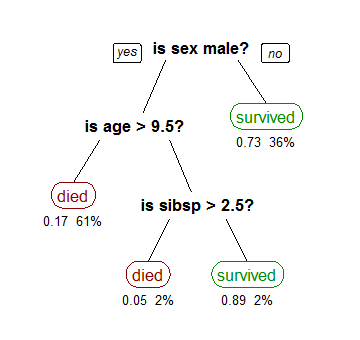

Para construir un árbol de decisión en Python, generalmente se utiliza la biblioteca scikit-learn.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# https://scikit-learn.org/stable/modules/tree.html#

# Crear el modelo de árbol de decisión

model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8962222222222223


Parámetros clave del DecisionTreeClassifier
Algunos de los parámetros más importantes en DecisionTreeClassifier de scikit-learn son:

- `criterion`: La función para medir la calidad de una división. "gini" para la impureza de Gini y "entropy" para la ganancia de información.
- `splitter`: La estrategia utilizada para elegir la división en cada nodo. Soporta "best" para elegir la mejor división y "random" para elegir la mejor división aleatoria.
- `max_depth`: La profundidad máxima del árbol. Limitar esto puede prevenir el sobreajuste.
- `min_samples_split`: El número mínimo de muestras requeridas para dividir un nodo interno.
- `min_samples_leaf`: El número mínimo de muestras requeridas para ser una hoja.
- `max_features`: El número de características a considerar cuando se busca la mejor división.

In [ ]:
pip install graphviz


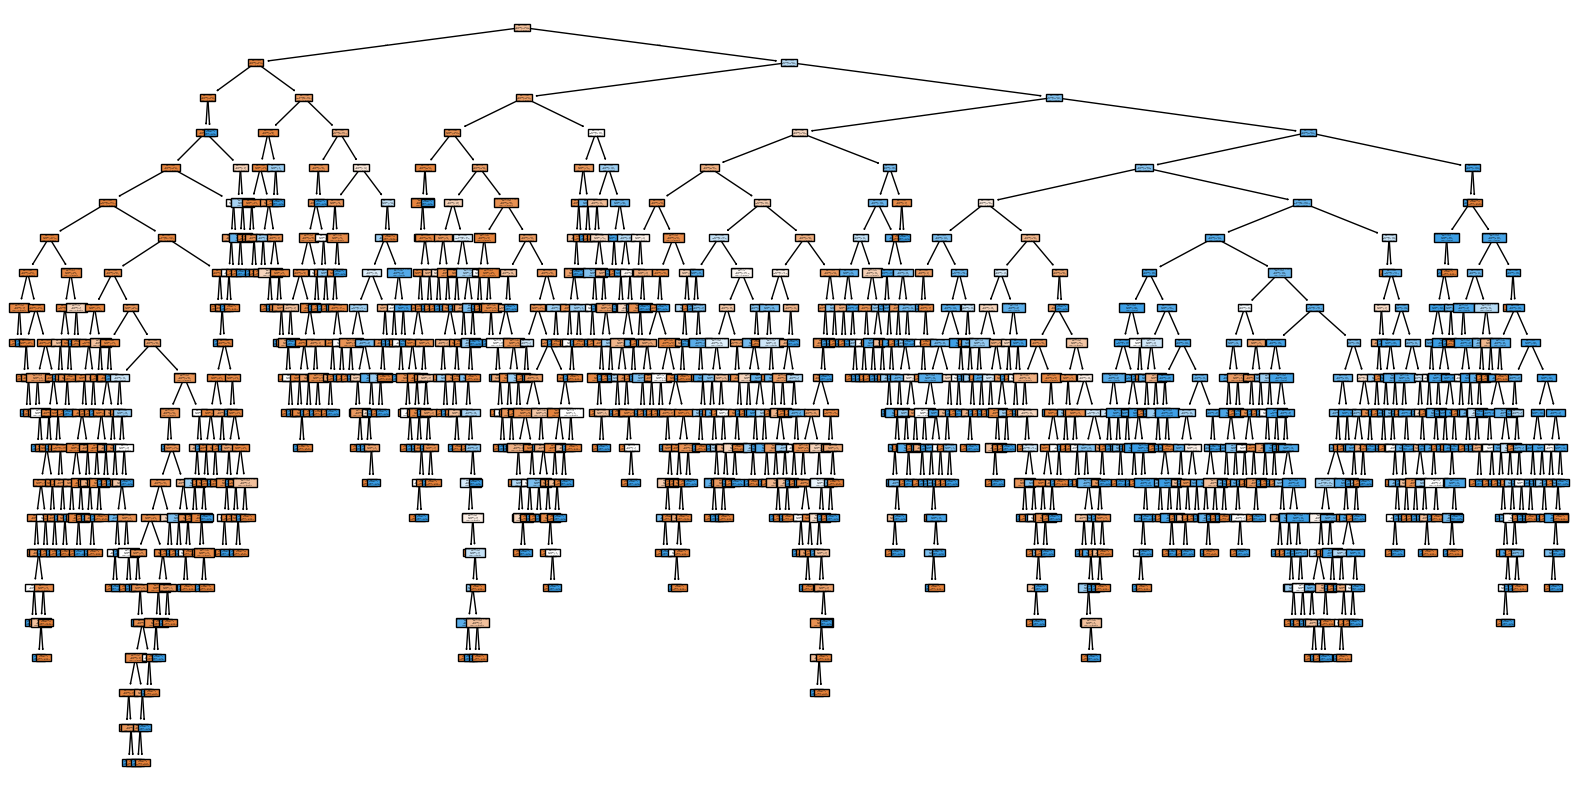

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar tamaño de la figura
plt.figure(figsize=(20,10))

# Visualizar el árbol
plot_tree(model, feature_names=caracteristica, class_names=["No Diabetes","Diabetes"], filled=True)

# Mostrar la figura
plt.show()


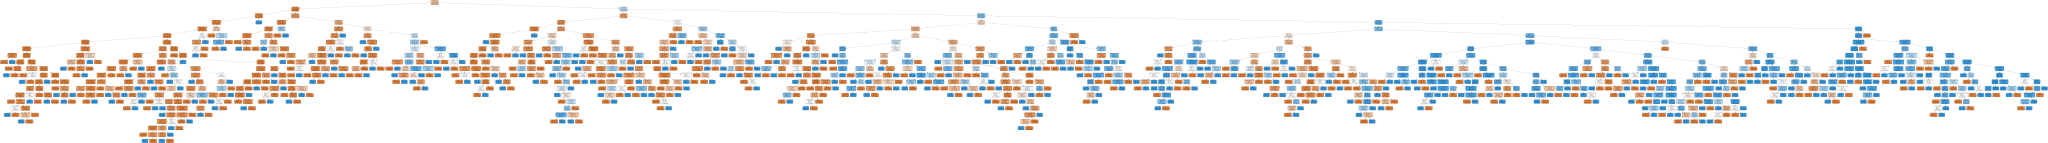

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Exportar el árbol en formato DOT
dot_data = export_graphviz(model, out_file=None,
                           feature_names=caracteristica,
                           class_names=["No Diabetes","Diabetes"],
                           filled=True, rounded=True,
                           special_characters=True)

# Crear el gráfico
graph = graphviz.Source(dot_data)
graph


In [ ]:
# Generar el gráfico pero en pdf
graph = graphviz.Source(dot_data)
graph.render("decision_tree")


'decision_tree.pdf'

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# https://scikit-learn.org/stable/modules/tree.html#

# Crear el modelo de árbol de decisión

model = DecisionTreeClassifier(random_state=42, max_depth = 2)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8531111111111112


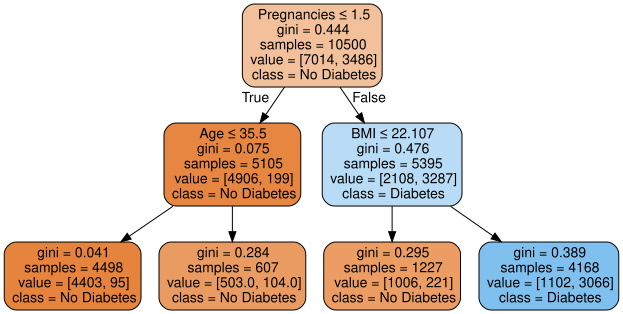

In [ ]:
from sklearn.tree import export_graphviz
import graphviz


dot_data = export_graphviz(model, out_file=None,
                           feature_names=caracteristica,
                           class_names=["No Diabetes","Diabetes"],
                           filled=True, rounded=True,
                           special_characters=True)


graph = graphviz.Source(dot_data)
graph


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# https://scikit-learn.org/stable/modules/tree.html#

# Crear el modelo de árbol de decisión

model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8962222222222223


Confusion Matrix:
 [[2763  223]
 [ 244 1270]] 

Accuracy: 0.8962222222222223
Overall Precision: 0.8506363027461487
Overall Recall: 0.8388375165125496
Overall F1 score: 0.8446957100099767
AUC: 0.8820778339428119


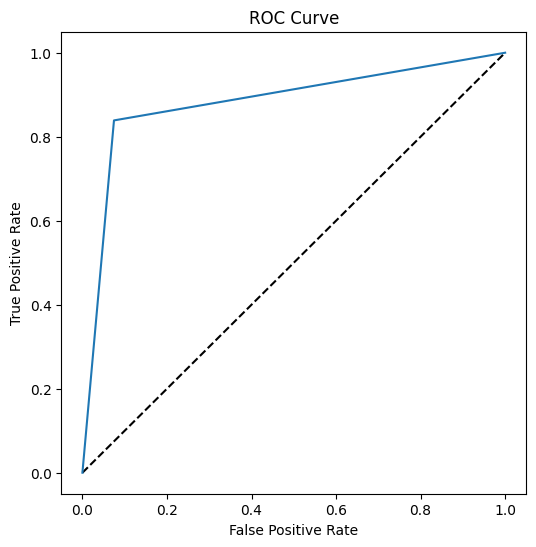

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Get predictions from test data
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Get evaluation metrics
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n',cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))
print("Overall F1 score:",f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo":"DecisionTreeClassifier",
"Accuracy":accuracy_score(y_test, predictions),
"Overall_Precision":precision_score(y_test, predictions),
"Overall_Recall":recall_score(y_test, predictions),
"Overall_F1":f1_score(y_test, predictions),
"AUC":f1_score(y_test, predictions),
}

# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)

In [ ]:
results_test

,Modelo,Accuracy,Overall_Precision,Overall_Recall,Overall_F1,AUC
0,LogisticRegression,0.838889,0.776454,0.731836,0.753485,0.920244
1,DecisionTreeClassifier,0.896222,0.850636,0.838838,0.844696,0.844696


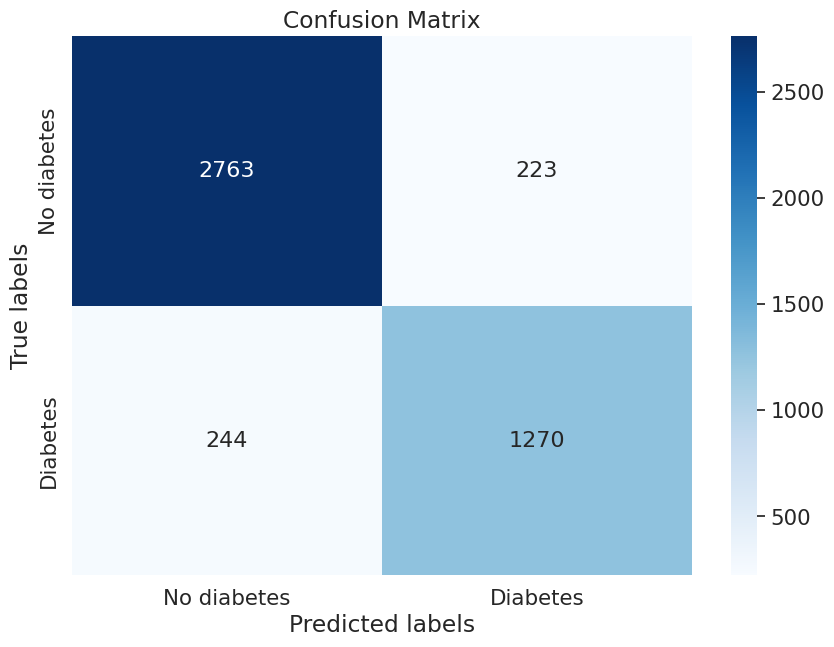

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

# Configurar la visualización con Seaborn
plt.figure(figsize=(10,7))
sns.set(font_scale=1.4)  # para etiquetas más grandes
sns.heatmap(cm, annot=True, annot_kws={"size": 16}, fmt='g', cmap="Blues",
            xticklabels=['No diabetes', 'Diabetes'], yticklabels=['No diabetes', 'Diabetes'])

# Etiquetas y título
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Define preprocessing for numeric columns (normalize them so they're on the same scale)
numeric_features = [0,1,2,3,4,5,6]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode the Age column)
categorical_features = [7]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('DecisionTreeClassifier', DecisionTreeClassifier())])


# fit the pipeline to train a logistic regression model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('DecisionTreeClassifier', DecisionTreeClassifier())])


In [ ]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('DecisionTreeClassifier', DecisionTreeClassifier())])

In [ ]:
# Evaluar el pipeline
y_pred_pipeline = pipeline.predict(X_test)
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
print(f"Accuracy with pipeline: {accuracy_pipeline}")


Accuracy with pipeline: 0.8853333333333333


## Random forest (bosque aleatorio)

Antes de comprender el funcionamiento del algoritmo Random Forest, debemos analizar la técnica de aprendizaje ensemble. Ensemble significa simplemente combinar múltiples modelos. De este modo, se utiliza una colección de modelos para realizar predicciones en lugar de un modelo individual.

Los algoritmos de ensemble pueden provenir de dos enfoques:

1. Bagging: Crea un subconjunto de entrenamiento diferente a partir del remuestreo con reemplazo y el resultado final se basa en la votación por mayoría. Por ejemplo, Random Forest.

2. Boosting: combina múltiples modelos de aprendizaje débiles en aprendices fuertes mediante la creación de modelos secuenciales. Por ejemplo, ADA BOOST, XG BOOST.

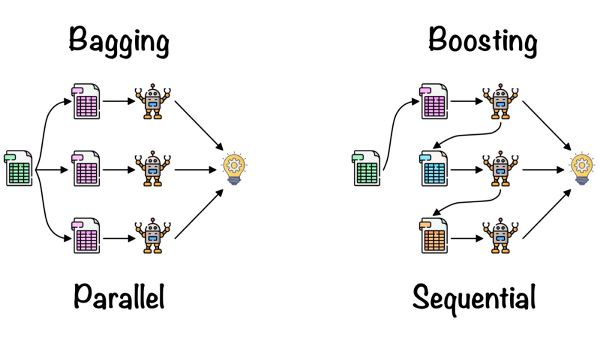

El Bagging, también conocido como Bootstrap Aggregation, es la técnica de ensamblaje utilizada por random forest. Bagging elige una muestra aleatoria/subconjunto aleatorio de todo el conjunto de datos. Por lo tanto, cada modelo se genera a partir de una de las muestras (muestras bootstrap) proporcionadas a partir de datos originales con reemplazo conocido como **muestreo de filas**. Este paso de muestreo de filas con sustitución se denomina bootstrap. Además del muestreo de filas existe uno en **columnas**, que permite aleatorizar las variables de entrada al modelo. Cabe destacar que cada modelo se entrena de forma independientemente. El resultado final se basa en la votación por mayoría tras combinar los resultados de todos los modelos. Este paso, que consiste en combinar todos los resultados y generar un resultado basado en la votación por mayoría, se conoce como agregación.

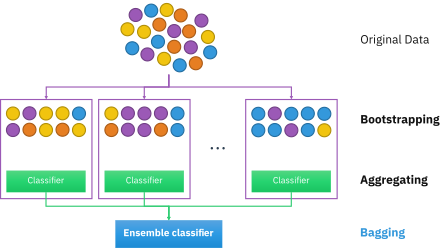

### Pasos del algoritmo Random Forest

Paso 1: En el modelo Random Forest, se selecciona un subconjunto de puntos de datos y un subconjunto de características para construir cada árbol de decisión. En pocas palabras, se toman n registros aleatorios y m características del conjunto de datos que tiene k registros.

Paso 2: Se construyen árboles de decisión individuales para cada muestra.

Paso 3: Cada árbol de decisión genera un resultado.

Paso 4: El resultado final se considera basado en la Votación por Mayoría o el Promedio para la Clasificación y la Regresión, respectivamente.

#### Votación de bosque aleatorio

Por ejemplo: considere la cesta de fruta como los datos que se muestran en la siguiente figura. Se toman n muestras de la cesta de fruta y se construye un árbol de decisión individual para cada muestra. Cada árbol de decisión generará un resultado, como se muestra en la figura. El resultado final se obtiene por mayoría. En la figura siguiente, se puede ver que el árbol de decisión mayoritario da como resultado una manzana en comparación con un plátano, por lo que el resultado final se toma como una manzana.

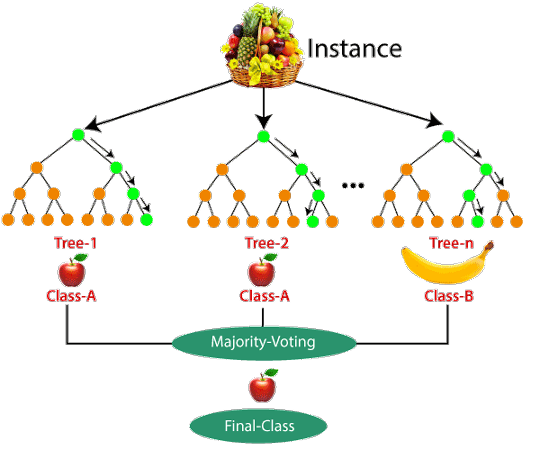

### Hiperpárametros

#### Hiperparámetros para aumentar el poder predictivo

* `n_estimators`: Número de árboles que el algoritmo construye para promediar las predicciones.

* `max_features`: Número máximo de características que el bosque aleatorio considera para dividir un nodo.

* `mini_sample_leaf`: Mínimo número de hojas requerido para dividir un nodo interno.

* `criterion`: Cómo dividir un nodo en cada árbol (Entropy/Gini impurity/Log Loss)

* `max_leaf_nodes`: Máxima cantidad de hojas en cada árbol.

#### Hiperparámetros para aumentar la rapidez

* `n_jobs`: cantidad de procesadores a usar. Si el valor es 1, solo se usará 1 procesador. Si es -1, no hay límite.

* `random_state`: controla la aleatoriedad del muestreo. El modelo producirá siempre el mismo resultado si el valor está definido (con mismos hiperparámetros y datos de entrenamiento).

* `oob_score`: "out of the bag" score. Método de cross-validation para bosques aleatorios. Un tercio del muestreo no es usado en el entrenamiento sino en la evaluación. Estos datos son llamados out-of-bag samples.

[Mas informacion del random forest](https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el pipeline de preprocesamiento y entrenamiento
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('rf', RandomForestClassifier(n_estimators=100))])

# Ejecutamos el pipeline para entrenar un random forest en el training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('rf', RandomForestClassifier())])


Veamos las métricas de rendimiento del nuevo modelo.

Confusion Matrix:
 [[2855  131]
 [ 184 1330]] 

Accuracy: 0.93
Overall Precision: 0.9103353867214237
Overall Recall: 0.8784676354029062
Overall F1 score: 0.8941176470588236
AUC: 0.9813815197473723


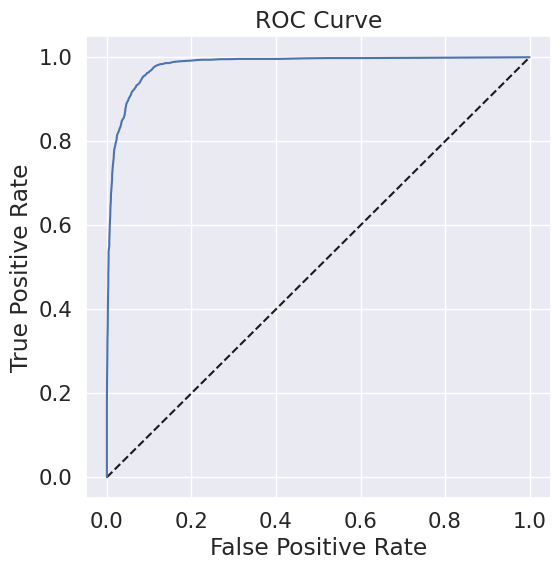

In [ ]:
# Obtenemos las predicciones sobre los datos de test
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Obtenemos las métricas de evaluación
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n', cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:", precision_score(y_test, predictions))
print("Overall Recall:", recall_score(y_test, predictions))
print("Overall F1 score:", f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# calculamos la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# graficamos la curva ROC
fig = plt.figure(figsize=(6, 6))
# Graficamos como línea rayada la diagonal 50%
plt.plot([0, 1], [0, 1], 'k--')
# Graficamos el FPR y el TPR de nuestro modelo
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo": "RandomForest",
"Accuracy": accuracy_score(y_test, predictions),
"Overall_Precision": precision_score(y_test, predictions),
"Overall_Recall": recall_score(y_test, predictions),
"Overall_F1": f1_score(y_test, predictions),
"AUC": roc_auc_score(y_test,y_scores[:,1]),
}
# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)

# Boosting

Los algoritmos de _Boosting_ son otra forma de construir un clasificador robusto a partir de clasificadores más simples. La idea es partir de un clasificador simple con todo el dataset y pasarle al siguiente solo las instancias que fueron mal clasificadas. De este modo, cada uno va "corrigiendo al anterior". Finalmente, para predecir, se combinan ponderadamente las respuestas de todos los clasificadores.

#### Ventajas del Boosting
* Es una de las técnicas más exitosas para resolver clasificación binaria.
* Es buena para manejar casos con datos faltantes.
* Focalizado en reducir el sesgo.

#### Desventajas del Boosting
* Es difícil de implementar sistemas de tiempo real por la complejidad temporal del algoritmo ya que es secuencial.
* La alta flexibilidad resulta en una gran cantidad de parámetros que afectan directamente el comportamiento del modelo.
* Si no se lo controla puede producir overfitting.

## XGB classifier

El *eXtreme Gradient Boost* (XGB) es un tipo de algoritmo de _Boosting_. No entraremos en el detalle matemático pero básicamente se resume a una aproximación mediante el cálculo de derivadas para optimizar el modelo.

* Paper: https://arxiv.org/pdf/1603.02754.pdf
* Doc: https://xgboost.readthedocs.io/en/latest/tutorials/model.html

In [ ]:
from xgboost import XGBClassifier

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('xgb', XGBClassifier())])

# fit the pipeline to train a random forest model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, d...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=N

Confusion Matrix:
 [[2870  116]
 [ 106 1408]] 

Accuracy: 0.9506666666666667
Overall Precision: 0.9238845144356955
Overall Recall: 0.9299867899603699
Overall F1 score: 0.9269256089532587
AUC: 0.9894905861877665


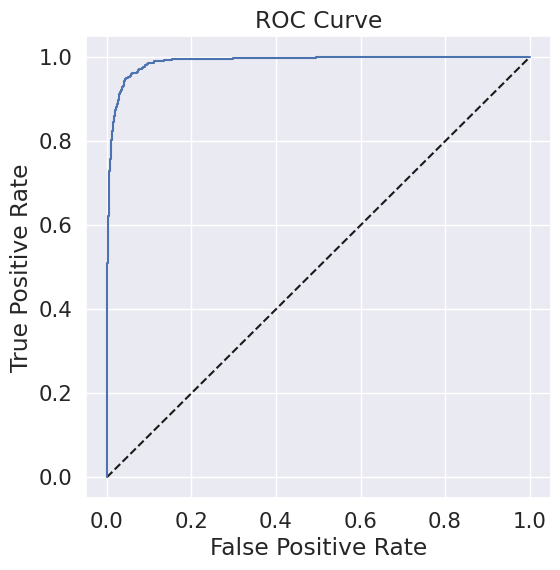

In [ ]:
# Get predictions from test data
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Get evaluation metrics
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n',cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))
print("Overall F1 score:",f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo":"XGBClassifier",
"Accuracy":accuracy_score(y_test, predictions),
"Overall_Precision":precision_score(y_test, predictions),
"Overall_Recall":recall_score(y_test, predictions),
"Overall_F1":f1_score(y_test, predictions),
"AUC":roc_auc_score(y_test,y_scores[:,1]),
}
# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)

In [ ]:
results_test

,Modelo,Accuracy,Overall_Precision,Overall_Recall,Overall_F1,AUC
0,LogisticRegression,0.838889,0.776454,0.731836,0.753485,0.920244
1,DecisionTreeClassifier,0.896222,0.850636,0.838838,0.844696,0.844696
2,RandomForest,0.931556,0.913580,0.879789,0.896366,0.982243
3,XGBClassifier,0.950667,0.923885,0.929987,0.926926,0.989491


En particular, es un buen algoritmo para:
* Problemas con datasets grandes (ya que el _Boosting_ mejora con iteraciones) y que el número de variables sea menor que el número de observaciones.
* Para problemas con una mezcla de variables categóricas y numéricas, o sólo numéricas (al contrario que la regresión lineal, el KNN o el K-Means, este algoritmo sí acepta variables categóricas tal cual están).

No es bueno para:
* En particular, Reconocimiento de Imágenes
* Problemas de Visión por Computador
* NLP

## LightGBM classifier

_LightGBM_ es otro algoritmo de _Boosting_. Es más rápido que XGB y tiene en general resultados bastante buenos.

Veamos cómo usarlo con nuestros datos para compararlo después con los otros algoritmos.

Doc: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

In [ ]:
from lightgbm import LGBMClassifier

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('lgbm', LGBMClassifier())])

# fit the pipeline to train a random forest model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

[LightGBM] [Info] Number of positive: 3486, number of negative: 7014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1177
[LightGBM] [Info] Number of data points in the train set: 10500, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.332000 -> initscore=-0.699153
[LightGBM] [Info] Start training from score -0.699153
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                             

Confusion Matrix:
 [[2867  119]
 [ 117 1397]] 

Accuracy: 0.9475555555555556
Overall Precision: 0.9215039577836411
Overall Recall: 0.9227212681638045
Overall F1 score: 0.9221122112211221
AUC: 0.989159671598238


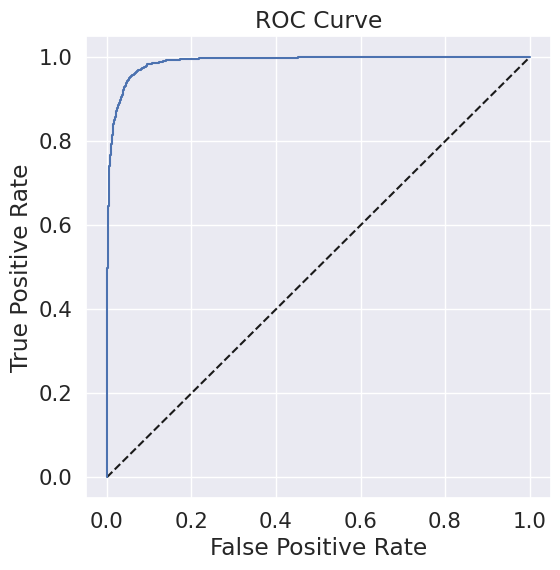

In [ ]:
# Get predictions from test data
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Get evaluation metrics
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n',cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))
print("Overall F1 score:",f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo":"LGBMClassifier",
"Accuracy":accuracy_score(y_test, predictions),
"Overall_Precision":precision_score(y_test, predictions),
"Overall_Recall":recall_score(y_test, predictions),
"Overall_F1":f1_score(y_test, predictions),
"AUC":roc_auc_score(y_test,y_scores[:,1]),
}
# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)

# Comparamos los modelos ajustados

In [ ]:
results_test

,Modelo,Accuracy,Overall_Precision,Overall_Recall,Overall_F1,AUC
0,LogisticRegression,0.838889,0.776454,0.731836,0.753485,0.920244
1,DecisionTreeClassifier,0.896222,0.850636,0.838838,0.844696,0.844696
2,RandomForest,0.931556,0.913580,0.879789,0.896366,0.982243
3,XGBClassifier,0.950667,0.923885,0.929987,0.926926,0.989491
4,LGBMClassifier,0.947556,0.921504,0.922721,0.922112,0.989160


El LGBMClassifier parece ser el algoritmo que mejor ajusta a los datos.

¡Esto se ve mejor!

## Usar el modelo para inferencias

Ahora que tenemos un modelo entrenado razonablemente útil, podemos guardarlo para usarlo más tarde para predecir etiquetas para nuevos datos:

In [ ]:
import joblib
#https://pypi.org/project/joblib/

# Guardamos el modelo como pickle
filename = 'diabetes_model.pkl'
joblib.dump(model, filename)

['diabetes_model.pkl']

El módulo Pickle de Python es un popular formato utilizado para serializar y deserializar tipos de datos. Este formato es nativo de Python, lo que significa que los objetos Pickle no pueden cargarse utilizando ningún otro lenguaje de programación.

Las funciones Pickle dump() y dumps() se utilizan para serializar un objeto. La única diferencia entre ellas es que dump() escribe los datos en un archivo, mientras que dumps() los representa como objeto byte.

Del mismo modo, load() lee objetos pickled de un archivo, mientras que loads() los deserializa de un objeto tipo bytes.

Cuando tenemos algunas observaciones nuevas cuya etiqueta es desconocida, podemos cargar el modelo y utilizarlo para predecir los valores de la etiqueta desconocida:

In [ ]:
# Cargamos el modelo
modeloCargado = joblib.load(filename)

# Predicción de un nuevo sample
# El modelo acepta un array de arrays de feature (así se predicen las clases de
# múltiples pacientes con un solo llamado
# Como ejemplo, creamos un arreglo con un solo elemento representando 1 paciente
X_new = np.array([[2, 180, 74, 24, 21, 23.9091702, 1.488172308, 22]])
print ('Nuevo sample:', format(list(X_new[0])))

# Obtenemos la predicción
pred = modeloCargado.predict(X_new)

# El modelo devuelve un arreglo de predicciones - un elemento por cada conjunto
# de features.
print('La clase predicha es', pred[0])

Nuevo sample: [np.float64(2.0), np.float64(180.0), np.float64(74.0), np.float64(24.0), np.float64(21.0), np.float64(23.9091702), np.float64(1.488172308), np.float64(22.0)]
La clase predicha es 1


**Ejercicio**

Ahora entrenen el algoritmo de maquina de soporte de vectores (SVM) de la libreria de scikit learn y determinen su metricas de rendimiento, cual de los algoritmos es el que se desempeña de mejor forma en esta base de datos.

Ayuda:

[Documentacion SVM](https://scikit-learn.org/stable/modules/svm.html#classification)

[LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[Informacion algoritmos](https://en.wikipedia.org/wiki/Support_vector_machine)

##### Respuesta

In [ ]:
from sklearn import svm

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('svc', svm.SVC(probability=True))])

# fit the pipeline to train a random forest model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('svc', SVC(probability=True))])


Confusion Matrix:
 [[2776  210]
 [ 219 1295]] 

Accuracy: 0.9046666666666666
Overall Precision: 0.8604651162790697
Overall Recall: 0.8553500660501981
Overall F1 score: 0.8578999668764492
AUC: 0.9643301280037798


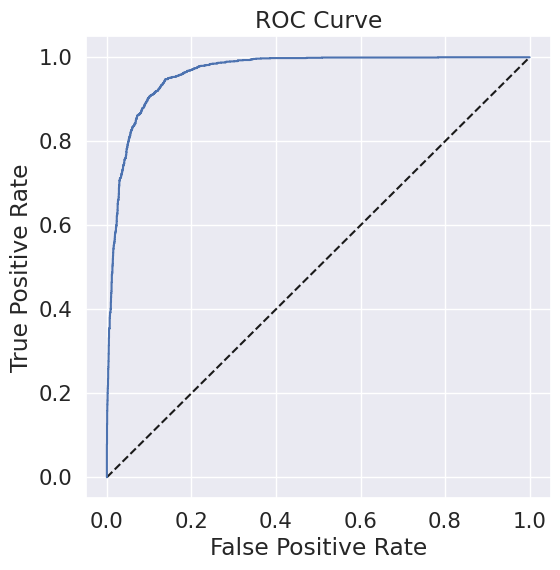

In [ ]:
# Get predictions from test data
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

# Get evaluation metrics
cm = confusion_matrix(y_test, predictions)
print ('Confusion Matrix:\n',cm, '\n')
print('Accuracy:', accuracy_score(y_test, predictions))
print("Overall Precision:",precision_score(y_test, predictions))
print("Overall Recall:",recall_score(y_test, predictions))
print("Overall F1 score:",f1_score(y_test, predictions))
auc = roc_auc_score(y_test,y_scores[:,1])
print('AUC: ' + str(auc))

# # calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# # plot ROC curve
fig = plt.figure(figsize=(6, 6))
# # Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# # Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

resultado_parcial = {"Modelo":"LGBMClassifier",
"Accuracy":accuracy_score(y_test, predictions),
"Overall_Precision":precision_score(y_test, predictions),
"Overall_Recall":recall_score(y_test, predictions),
"Overall_F1":f1_score(y_test, predictions),
"AUC":roc_auc_score(y_test,y_scores[:,1]),
}
# Crear un DataFrame a partir del diccionario resultado_parcial
df_parcial = pd.DataFrame([resultado_parcial])

# Usar pd.concat para agregar df_parcial a results_test
results_test = pd.concat([results_test, df_parcial], ignore_index=True)

In [ ]:
results_test

,Modelo,Accuracy,Overall_Precision,Overall_Recall,Overall_F1,AUC
0,LogisticRegression,0.838889,0.776454,0.731836,0.753485,0.920244
1,DecisionTreeClassifier,0.896222,0.850636,0.838838,0.844696,0.844696
2,RandomForest,0.931556,0.913580,0.879789,0.896366,0.982243
3,XGBClassifier,0.950667,0.923885,0.929987,0.926926,0.989491
4,LGBMClassifier,0.947556,0.921504,0.922721,0.922112,0.989160
5,LGBMClassifier,0.904667,0.860465,0.855350,0.857900,0.964330


# Clasificación multiclase

Las técnicas de clasificación binarias funcionan bien cuando las observaciones de los datos pertenecen a una de dos clases o categorías, como "Verdadero" o "Falso".

Cuando los datos pueden clasificarse en más de dos clases, debe utilizar un algoritmo de clasificación multiclase.

La clasificación multiclase puede considerarse como una combinación de varios clasificadores binarios. Hay dos maneras de abordar el problema:

- **Uno contra el resto (OVR)**, en la que se crea un clasificador para cada posible valor de clase, con un resultado positivo para los casos en los que la predicción es *esta* clase, y predicciones negativas para los casos en los que la predicción es cualquier otra clase. Un problema de clasificación con cuatro posibles clases de forma (*cuadrado*, *círculo*, *triángulo*, *hexágono*) requeriría cuatro clasificadores que predijeran:
    - *cuadrado* o no
    - *círculo* o no
    - *triángulo* o no
    - *hexágono* o no
    
- **Uno contra uno (OVO)**, en el que se crea un clasificador para cada posible par de clases. El problema de clasificación con cuatro clases de formas requeriría los siguientes clasificadores binarios:
    - *cuadrado* o *círculo*
    - *cuadrado* o *triángulo*
    - *cuadrado* o *hexágono*
    - *círculo* o *triángulo*
    - *círculo* o *hexágono*
    - *triángulo* o *hexágono*

En ambos enfoques, el modelo global que combina los clasificadores genera un vector de predicciones en el que las probabilidades generadas a partir de los clasificadores binarios individuales se utilizan para determinar qué clase predecir.

Afortunadamente, en la mayoría de los marcos de aprendizaje automático, incluyendo scikit-learn, la implementación de un modelo de clasificación multiclase no es significativamente más compleja que la clasificación binaria - y en la mayoría de los casos, los estimadores utilizados para la clasificación binaria soportan implícitamente la clasificación multiclase abstrayendo un algoritmo OVR, un algoritmo OVO, o permitiendo una elección de cualquiera de ellos.

> **Más información**: Para obtener más información sobre el soporte de estimadores para la clasificación multiclase en Scikit-Learn, consulte la [documentación de Scikit-Learn](https://scikit-learn.org/stable/modules/multiclass.html).

### Problema multiclase

#### Explorar los datos

Empecemos examinando un conjunto de datos que contenga observaciones de múltiples clases. Utilizaremos un conjunto de datos que contiene observaciones de tres especies diferentes de pingüinos.

> **Cita**: El conjunto de datos de pingüinos utilizado en este ejercicio es un subconjunto de los datos recogidos y puestos a disposición por [Dr. Kristen
Gorman](https://www.uaf.edu/cfos/people/faculty/detail/kristen-gorman.php)
y la [Estación Palmer, Antártida LTER](https://pal.lternet.edu/), miembros de la [Red de Investigación Ecológica
Network](https://lternet.edu/).

In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'penguins.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

penguins = pd.read_csv(ruta_archivo)
sample = penguins.sample(10)
sample

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
195,49.6,15.0,216.0,4750.0,1
211,50.4,15.3,224.0,5550.0,1
161,46.8,15.4,215.0,5150.0,1
334,50.2,18.8,202.0,3800.0,2
22,35.9,19.2,189.0,3800.0,0
35,39.2,21.1,196.0,4150.0,0
66,35.5,16.2,195.0,3350.0,0
258,41.7,14.7,210.0,4700.0,1
123,41.4,18.5,202.0,3875.0,0
187,48.4,16.3,220.0,5400.0,1


In [ ]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        344 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 13.6 KB


In [ ]:
penguins.describe().T

,count,mean,std,min,25%,50%,75%,max
CulmenLength,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
CulmenDepth,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
FlipperLength,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
BodyMass,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0
Species,344.0,0.755814,0.762626,0.0,0.000,1.00,1.0,2.0


El conjunto de datos contiene las siguientes columnas:
* **CulmenLength** (Longitud culmen): La longitud en mm del culmen (pico) del pingüino.
* **CulmenDepth** (Profundidad del culmen): La profundidad en mm del culmen del pingüino.
* **FlipperLength** (Longitud de la aleta): Longitud en mm de la aleta del pingüino.
* **BodyMass** (Masa corporal): La masa corporal del pingüino en gramos.
* **Species** (Especie): Un valor entero que representa la especie del pingüino.

La columna **Species** es la etiqueta para cuya predicción queremos entrenar un modelo. El conjunto de datos incluye tres especies posibles, que se codifican como 0, 1 y 2. Los nombres reales de las especies se revelan mediante el nombre del pingüino.

In [ ]:
penguin_classes = ['Adelie', 'Gentoo', 'Chinstrap']
print(sample.columns, 'SpeciesName')
for index, row in penguins.sample(10).iterrows():
    print('[',row[0], row[1], row[2], row[3], int(row[4]),']',penguin_classes[int(row[4])])

Index(['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass', 'Species'], dtype='object') SpeciesName
[ 47.5 14.0 212.0 4875.0 1 ] Gentoo
[ 35.9 19.2 189.0 3800.0 0 ] Adelie
[ 36.0 18.5 186.0 3100.0 0 ] Adelie
[ 49.6 18.2 193.0 3775.0 2 ] Chinstrap
[ 44.9 13.8 212.0 4750.0 1 ] Gentoo
[ 34.5 18.1 187.0 2900.0 0 ] Adelie
[ 43.1 19.2 197.0 3500.0 0 ] Adelie
[ 48.2 15.6 221.0 5100.0 1 ] Gentoo
[ 47.4 14.6 212.0 4725.0 1 ] Gentoo
[ 50.0 15.2 218.0 5700.0 1 ] Gentoo


Ahora que sabemos lo que representan las características y las etiquetas de los datos, vamos a explorar el conjunto de datos. En primer lugar, veamos si faltan valores (*nulos*).

In [ ]:
# Count the number of null values for each column
penguins.isnull().sum()

,0
CulmenLength,2
CulmenDepth,2
FlipperLength,2
BodyMass,2
Species,0


Parece que faltan algunos valores de características, pero no faltan etiquetas. Profundicemos un poco más y veamos las filas que contienen nulos.

In [ ]:
# Show rows containing nulls
penguins[penguins.isnull().any(axis=1)]

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
3,NaN,NaN,NaN,NaN,0
271,NaN,NaN,NaN,NaN,1


Hay dos filas que no contienen ningún valor de característica (*NaN* significa "no es un número"), por lo que no serán útiles para entrenar un modelo. Descartémoslas del conjunto de datos.

In [ ]:
penguins['Species'].value_counts()

,count
Species,
0,152
1,124
2,68


In [ ]:

penguins=penguins.dropna()

penguins.isnull().sum()


,0
CulmenLength,0
CulmenDepth,0
FlipperLength,0
BodyMass,0
Species,0


Ahora que ya nos hemos ocupado de los valores que faltan, vamos a explorar cómo se relacionan las características con la etiqueta creando algunos gráficos de caja.

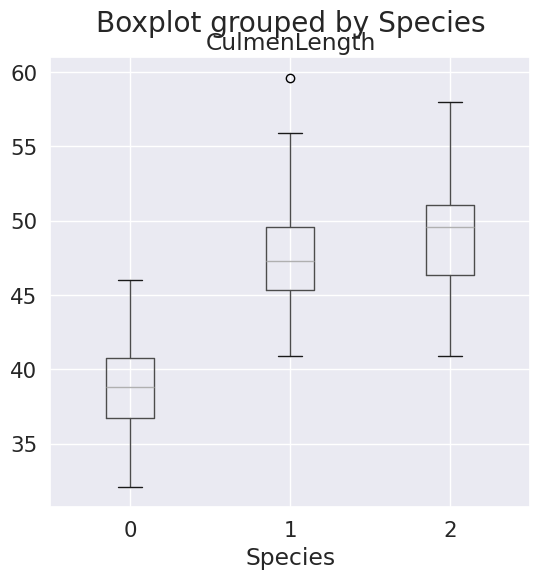

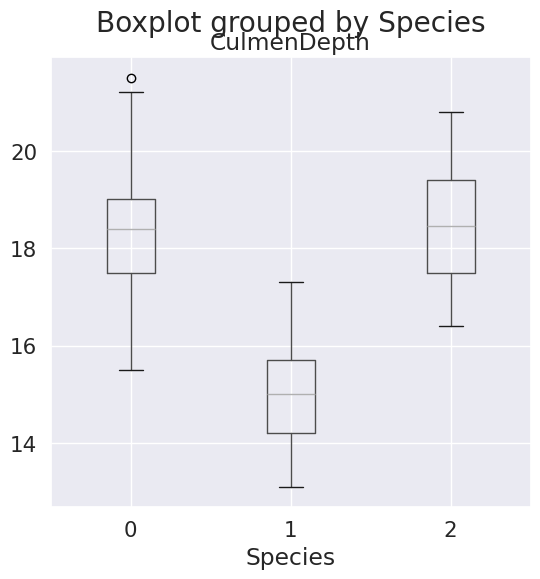

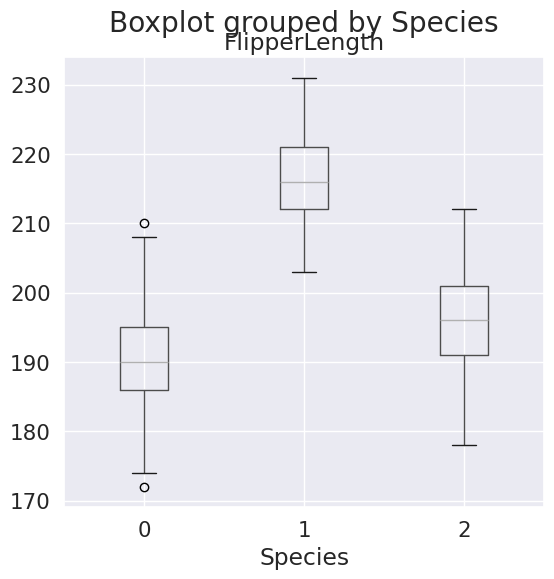

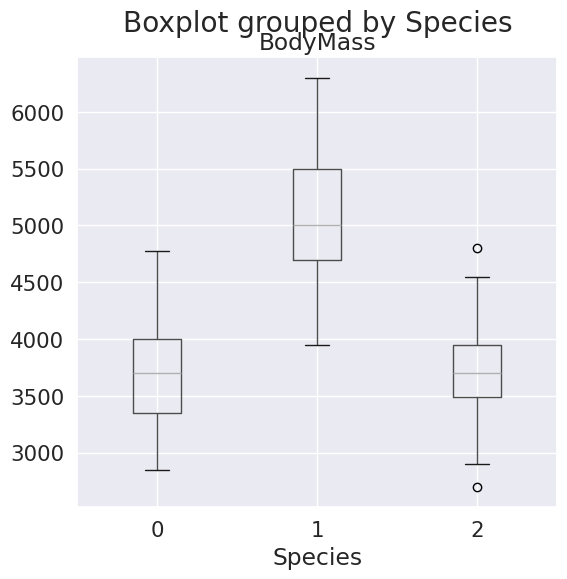

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

penguin_features = ['CulmenLength','CulmenDepth','FlipperLength','BodyMass']
penguin_label = 'Species'
for col in penguin_features:
    penguins.boxplot(column=col, by=penguin_label, figsize=(6,6))
    plt.title(col)
plt.show()

A partir de los gráficos de caja, parece que las especies 0 y 2 (Amelie y Chinstrap) tienen perfiles de datos similares para la profundidad del culmen, la longitud de las aletas y la masa corporal, pero las Chinstraps tienden a tener culmos más largos. La especie 1 (Gentoo) tiende a tener características claramente diferenciadas de las demás, lo que debería ayudarnos a entrenar un buen modelo de clasificación.

### Preparar los datos

Al igual que para la clasificación binaria, antes de entrenar el modelo, tenemos que separar las características y la etiqueta, y luego dividir los datos en subconjuntos para el entrenamiento y la validación. También aplicaremos una técnica de *estratificación* al dividir los datos para mantener la proporción de cada valor de etiqueta en los conjuntos de datos de entrenamiento y validación.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and labels
penguins_X, penguins_y = penguins[penguin_features].values, penguins[penguin_label].values

# Split data 70%-30% into training set and test set
x_penguin_train, x_penguin_test, y_penguin_train, y_penguin_test = train_test_split(penguins_X, penguins_y,
                                                                                    test_size=0.30,
                                                                                    random_state=0,
                                                                                    stratify=penguins_y)

print ('Training Set: %d, Test Set: %d \n' % (x_penguin_train.shape[0], x_penguin_test.shape[0]))

Training Set: 239, Test Set: 103 



### Entrenar y evaluar un clasificador multiclase

Ahora que tenemos un conjunto de características de entrenamiento y las etiquetas de entrenamiento correspondientes, podemos ajustar un algoritmo de clasificación multiclase a los datos para crear un modelo. La mayoría de los algoritmos de clasificación de scikit-learn soportan inherentemente la clasificación multiclase. Probaremos con un algoritmo de regresión logística.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Set regularization rate
reg = 0.1

# train a logistic regression model on the training set
multi_model = LogisticRegression(C=1/reg, solver='lbfgs', multi_class='auto', max_iter=10000).fit(x_penguin_train, y_penguin_train)
print (multi_model)

LogisticRegression(C=10.0, max_iter=10000, multi_class='auto')


Ahora podemos utilizar el modelo entrenado para predecir las etiquetas de las características de prueba y comparar las etiquetas predichas con las etiquetas reales:

In [ ]:
penguin_predictions = multi_model.predict(x_penguin_test)
print('Predicted labels: ', penguin_predictions[:15])
print('Actual labels   : ' ,y_penguin_test[:15])

Predicted labels:  [0 1 0 2 2 1 1 1 0 2 2 1 2 1 2]
Actual labels   :  [0 1 2 2 2 1 1 1 0 2 2 1 2 1 2]


Veamos un informe de clasificación.

In [ ]:
from sklearn. metrics import classification_report

print(classification_report(y_penguin_test, penguin_predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       1.00      1.00      1.00        37
           2       0.95      0.90      0.93        21

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



Al igual que con la clasificación binaria, el informe incluye las métricas de *precision* y *recall* para cada clase. Sin embargo, mientras que con la clasificación binaria podríamos centrarnos en las puntuaciones de la clase *positiva*; en este caso, hay múltiples clases, por lo que tenemos que mirar una métrica global (ya sea la macro o la media ponderada) para tener una idea de lo bien que funciona el modelo en las tres clases.

Puede obtener las métricas globales por separado del informe utilizando las clases de puntuación de métricas de scikit-learn, pero con los resultados multiclase debe especificar qué métrica media desea utilizar para la precisión y la recuperación.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Overall Accuracy:",accuracy_score(y_penguin_test, penguin_predictions))
print("Overall Precision:",precision_score(y_penguin_test, penguin_predictions, average=None))
print("Overall Recall:",recall_score(y_penguin_test, penguin_predictions, average=None))

Overall Accuracy: 0.970873786407767
Overall Precision: [0.95652174 1.         0.95      ]
Overall Recall: [0.97777778 1.         0.9047619 ]


Veamos ahora la matriz de confusión de nuestro modelo:



In [ ]:
from sklearn.metrics import confusion_matrix

# Print the confusion matrix
mcm = confusion_matrix(y_penguin_test, penguin_predictions)
print(mcm)

[[44  0  1]
 [ 0 37  0]
 [ 2  0 19]]


La matriz de confusión muestra la intersección entre los valores predichos y los valores reales de las etiquetas para cada clase: en términos sencillos, las intersecciones diagonales de arriba a la izquierda indican el número de predicciones correctas.

Cuando se trata de múltiples clases, suele ser más intuitivo visualizar esto como un mapa de calor, como éste:

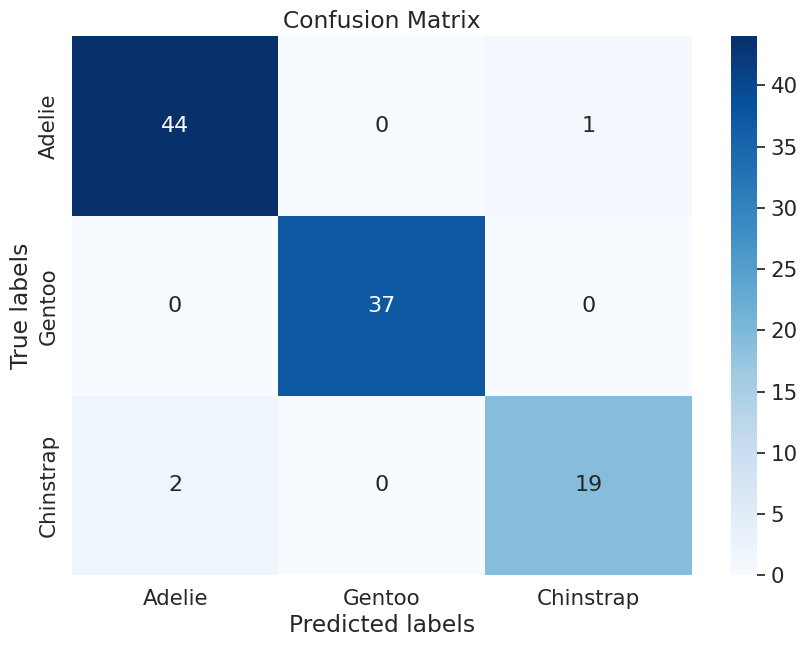

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



# Configurar la visualización con Seaborn
plt.figure(figsize=(10,7))
sns.set(font_scale=1.4)  # para etiquetas más grandes
sns.heatmap(mcm, annot=True, annot_kws={"size": 16}, fmt='g', cmap="Blues",
            xticklabels=penguin_classes, yticklabels=penguin_classes)

# Etiquetas y título
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

Los cuadrados más oscuros en el gráfico de la matriz de confusión indican un gran número de casos, y es de esperar que pueda ver una línea diagonal de cuadrados más oscuros que indican los casos en los que la etiqueta predicha y la real son iguales.

En el caso de un modelo de clasificación multiclase, no es posible una curva ROC única que muestre la tasa de verdaderos positivos frente a la tasa de falsos positivos. Sin embargo, puede utilizar las tasas de cada clase en una comparación Uno contra Resto (OVR) para crear un gráfico ROC para cada clase.

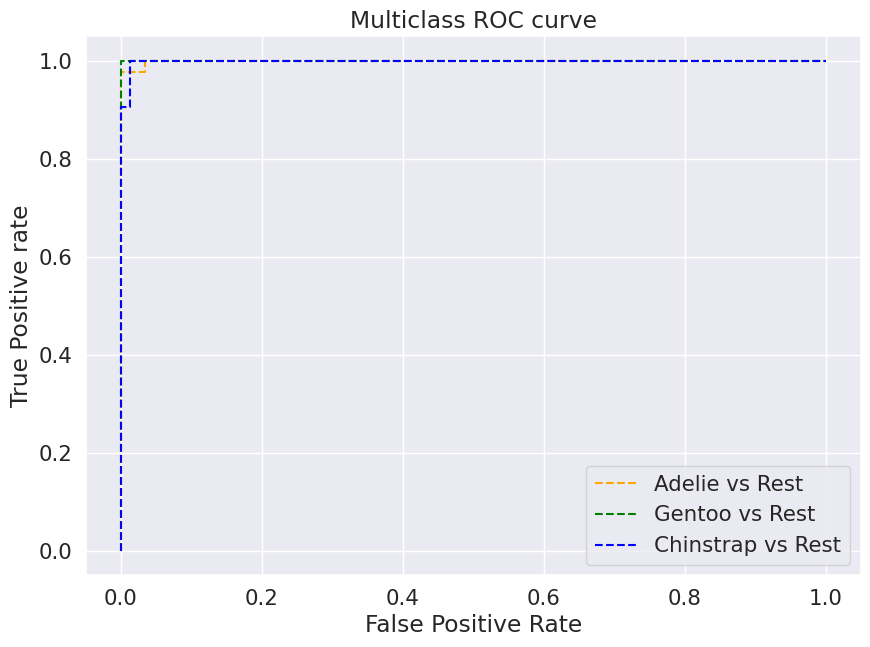

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Get class probability scores
penguin_prob = multi_model.predict_proba(x_penguin_test)
plt.figure(figsize=(10,7))
# Get ROC metrics for each class
fpr = {}
tpr = {}
thresh ={}
for i in range(len(penguin_classes)):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_penguin_test, penguin_prob[:,i], pos_label=i)

# Plot the ROC chart
colors = ['orange','green','blue']
for i in range(len(penguin_classes)):
  plt.plot(fpr[i], tpr[i], linestyle='--',color=colors[i], label=penguin_classes[i] + ' vs Rest')
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.show()

Para cuantificar el rendimiento ROC, puede calcular una puntuación agregada del área bajo la curva que se promedia en todas las curvas OVR.

In [ ]:
auc = roc_auc_score(y_penguin_test,penguin_prob, multi_class='ovr')
print('Average AUC:', auc)

Average AUC: 0.9993574254297553


### Preprocesar los datos en una canalización

De nuevo, al igual que con la clasificación binaria, puede utilizarse un pipeline para aplicar los pasos de preprocesamiento a los datos antes de ajustar un modelo. Veamos si podemos mejorar el predictor pingüino escalando las variables numéricas en un paso de transformación antes del entrenamiento. También probaremos otro algoritmo diferente (una máquina de vectores soporte).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Define preprocessing for numeric columns (scale them)
feature_columns = [0,1,2,3]
feature_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
    ])

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('preprocess', feature_transformer, feature_columns)])

# Create training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', SVC(probability=True))])


# fit the pipeline to train a linear regression model on the training set
multi_model = pipeline.fit(x_penguin_train, y_penguin_train)
print (multi_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3])])),
                ('regressor', SVC(probability=True))])


Ahora podemos evaluar el nuevo modelo.

In [ ]:
# Print the confusion matrix
mcm = confusion_matrix(y_penguin_test, penguin_predictions)
print(mcm)

[[44  0  1]
 [ 0 37  0]
 [ 2  0 19]]


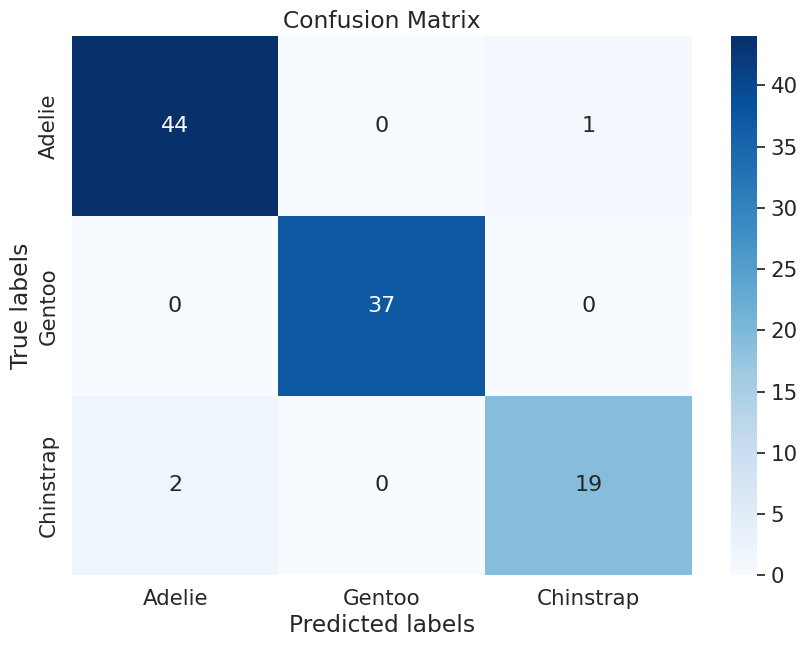

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



# Configurar la visualización con Seaborn
plt.figure(figsize=(10,7))
sns.set(font_scale=1.4)  # para etiquetas más grandes
sns.heatmap(mcm, annot=True, annot_kws={"size": 16}, fmt='g', cmap="Blues",
            xticklabels=penguin_classes, yticklabels=penguin_classes)

# Etiquetas y título
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

### Utilizar el modelo con nuevas observaciones de datos

Ahora vamos a guardar nuestro modelo entrenado para poder utilizarlo de nuevo más tarde.

In [ ]:
import joblib

# Save the model as a pickle file
filename = 'penguin_model.pkl'
joblib.dump(multi_model, filename)

['penguin_model.pkl']

Bien, ya tenemos un modelo entrenado. Usémoslo para predecir la clase de una nueva observación de un pingüino:

In [ ]:
# Load the model from the file
multi_model = joblib.load(filename)

# The model accepts an array of feature arrays (so you can predict the classes of multiple penguin observations in a single call)
# We'll create an array with a single array of features, representing one penguin
x_new = np.array([[50.4, 15.3, 224, 5550]])
print ('New sample: {}'.format(x_new[0]))

# The model returns an array of predictions - one for each set of features submitted
# In our case, we only submitted one penguin, so our prediction is the first one in the resulting array.
penguin_pred = multi_model.predict(x_new)[0]
print('Predicted class is', penguin_classes[penguin_pred])

New sample: [  50.4   15.3  224.  5550. ]
Predicted class is Gentoo


También se puede enviar un lote de observaciones de pingüinos al modelo y obtener una predicción para cada una de ellas.

In [ ]:
# This time our input is an array of two feature arrays
x_new = np.array([[49.5, 18.4, 195, 3600],
                  [38.2, 20.1, 190, 3900]])
print ('New samples:\n{}'.format(x_new))

# Call the web service, passing the input data
predictions = multi_model.predict(x_new)

# Get the predicted classes.
for prediction in predictions:
    print(prediction, '(' + penguin_classes[prediction] +')')

New samples:
[[  49.5   18.4  195.  3600. ]
 [  38.2   20.1  190.  3900. ]]
2 (Chinstrap)
0 (Adelie)


# Lectura adicional

La clasificación es una de las formas más comunes de aprendizaje automático, y siguiendo los principios básicos que hemos discutido en este notebook deberías ser capaz de entrenar y evaluar modelos de clasificación con scikit-learn. Merece la pena dedicar algún tiempo a investigar los algoritmos de clasificación en mayor profundidad, y un buen punto de partida es la [documentación de Scikit-Learn](https://scikit-learn.org/stable/user_guide.html).